<a href="https://colab.research.google.com/github/WilmaDarc/Projeto__final/blob/main/projeto_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img width="1347" height="392" alt="image" src="https://github.com/user-attachments/assets/df0f71b5-7bae-4751-a85c-92f9cfbf61af" />
<a href="https://github.com/WilmaDarc/volta-zero-/tree/main">

**Profissão: Cientista de Dados**

**PROJETO | PARCERIA SEMANTIX**


**Aluna:[Wilma Darc Alves de Farias](www.linkedin.com/in/wilma-farias-66a15962)<br>**
**Data: Dezembro 2025.**

## **Bibliotecas e Pacotes Utilizados**

In [90]:
# Importando as bibliotecas necessárias:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.metrics import recall_score, f1_score, precision_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## **Coleta de Dados**


Conjunto de dados utilizado é [Credit Card Fraud Detection Dataset no Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), que contém transações realizadas com cartões de crédito em setembro de 2013 por titulares de cartões europeus. Este conjunto de dados é altamente desequilibrado, com fraudes representando apenas 0,172% de todas as transações.

**Detalhes sobre as variáveis:**

V1, V2, ... V28: Estas são as principais componentes obtidas. Porém, devido a questões de confidencialidade, os recursos originais e mais informações básicas sobre os dados não estão disponíveis.

Time: Esta coluna contém os segundos decorridos entre cada transação e a primeira transação no conjunto de dados.

Amount: É o valor da transação.

Class: Esta é a variável de resposta e é o elemento que se busca prever, assumindo:

1 Para transações FRAUDULENTAS

0 Para transações NÃO FRAUDULENTAS


In [1]:
from google.colab import files

# Faz upload do arquivo
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [91]:
# Leitura do CSV
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Processamento de Dados**

In [92]:
# Verificando se há colunas com valores não numéricos:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [93]:
# Verificando se há valores nulos:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [94]:
# Comparando o número de transações não fraudulentas e fraudulentas:
df.Class.value_counts()

,count
Class,
0,284315
1,492


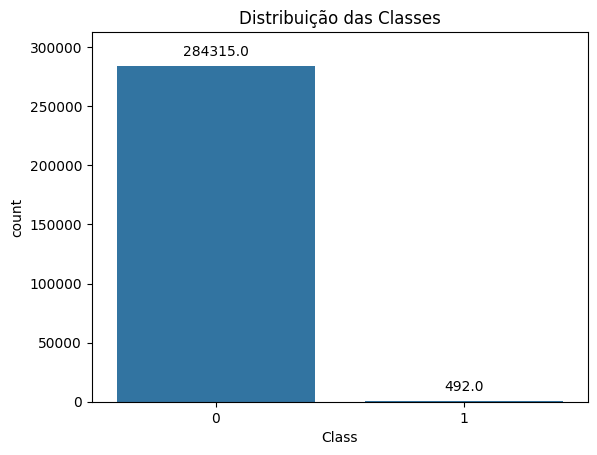

In [95]:
# Visualizando a distribuição das classes
ax = sns.countplot(x='Class', data=df)
plt.title('Distribuição das Classes')

# Adicionando a contagem em cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Ajustando os Limites do eixo y para acomodar o texto
ax.set_ylim(0, 1.1 * df['Class'].value_counts().max())
plt.show()



Porquanto, o número de transações não fraudulentas (284.315) é muito maior do que o número de transações fraudulentas (492). Isso é um exemplo de um conjunto de dados desbalanceado, onde a classe de interesse (neste caso, transações fraudulentas) é muito menos frequente do que a outra classe.

##**Análise Exploratória de Dados**


In [96]:
# Análise exploratória dos dados
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [97]:
# Verificando os tipos de dados NÃO FRAUDE:
df_nao_fraude = df.Amount[df.Class == 0]
df_nao_fraude.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


**Transações Não Fraudulentas (Não Fraude):**

1. Há um total de 284.315 transações não fraudulentas.

2. O valor médio dessas transações é de aproximadamente $88.29.

3. O valor máximo de uma transação não fraudulenta é $25.691,16, o que é bastante alto.

4. A maioria das transações não fraudulentas (75%) tem um valor abaixo de $77.05, indicando que a maioria das transações não fraudulentas são de valores relativamente baixos.

In [98]:
# Verificando os tipos de dados FRAUDE:
df_fraude = df.Amount[df.Class == 1]
df_fraude.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


**Transações Fraudulentas (Fraude):**

1. Nos dados analisados existe um total de 492 de transações fraudulentas, o que é expressivamente menor em comparação com as transações não fraudulentas.

2. O valor médio dessas transações fraudulentas é de aproximadamente $122.21, que é maior do que o valor médio das transações não fraudulentas.

3. O valor máximo de uma transação fraudulenta é $2.125,87, que é muito menor do que o valor máximo de uma transação não fraudulenta.

4. A maioria das transações fraudulentas (75%) tem um valor  de $105.89, o que é maior do que o valor correspondente para transações não fraudulentas.

Ainda que, as transações fraudulentas sejam muito menos frequentes, elas tendem a ter valores maiores em média. Entretanto, o valor máximo para transações fraudulentas é muito menor do que para transações não fraudulentas. Isso sugere que, embora os fraudadores tendam a fazer transações de valor maior em média, eles evitam fazer transações de valores extremamente altos, possivelmente para tentar evitar detecção.

Um conjuntos de dados desbalanceados podem ser um desafio para modelos de aprendizado de máquina, pois eles tendem a ser enviesados para a classe majoritária e podem ter um desempenho ruim na classe minoritária. Desse modo, será feito undersampling para equilibrar a distribuição de classes melhorando o desempenho do modelo na classe minoritária.

In [100]:
# Separando os dados de acordo com o tipo de transação:
# Transações fraudulentas
df_fraude = df[df.Class == 1]
# Transações não fraudulentas
df_nao_fraude = df[df.Class ==0]

In [101]:
# Reduzindo a classe não fraudulenta
df_nao_fraude_reduzido = df_nao_fraude.sample(n=492, random_state=123)
# O random_state é usado para garantir a reprodutibilidade dos resultados.

# Combinando a classe fraudulenta com a classe não fraudulenta reduzida:
df_balanceado = pd.concat([df_nao_fraude_reduzido, df_fraude], axis = 0)

# Exibindo a nova contagem de classes:
print(df_balanceado.Class.value_counts())


Class
0    492
1    492
Name: count, dtype: int64


In [103]:
# Ajustando o INDEX:
df_balanceado.reset_index(inplace=True)

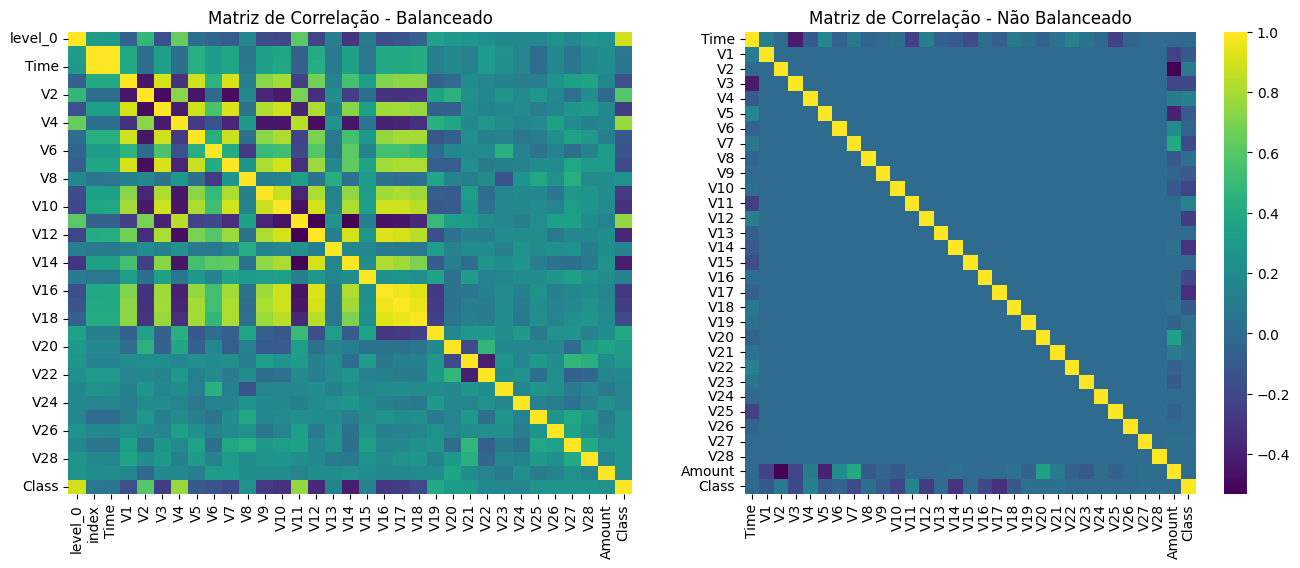

In [104]:
# Calcula a matriz de correlação para cada DataFrame
corr_balanceado = df_balanceado.corr()
corr_nao_balanceado = df.corr()

# Cria uma figura para conter os dois heatmaps
plt.figure(figsize=(16, 6))

# Cria o primeiro subplot para a matriz de correlação do df_balanceado
plt.subplot(1, 2, 1)
sns.heatmap(corr_balanceado, cmap='viridis', cbar=False)
plt.title('Matriz de Correlação - Balanceado')

# Cria o segundo subplot para a matriz de correlação do df_nao_balanceado
plt.subplot(1, 2, 2)
sns.heatmap(corr_nao_balanceado, cmap='viridis')
plt.title('Matriz de Correlação - Não Balanceado')

# Mostra a figura com os dois heatmaps
plt.show()

**Matriz de Correlação - Balanceado:** Esta matriz mostra uma variedade de correlações entre as variáveis. A intensidade das cores varia, indicando diferentes níveis de força de correlação. A linha diagonal de amarelo do canto superior esquerdo ao canto inferior direito mostra que cada variável tem uma correlação perfeita consigo mesma, como previsto.

**Matriz de Correlação - Não Balanceado:** Esta matriz mostra principalmente correlações baixas ou inexistentes, como indicado pela cor verde predominante. Existe menos variações na intensidade da cor em comparação com a matriz balanceada, indicando menos variação na força das correlações. A linha diagonal de amarelo é consistente com a matriz balanceada, mostrando a correlação perfeita de cada variável consigo mesma.

Observa-se que, a matriz dos dados balanceados mostra uma maior variedade de correlações entre as variáveis, enquanto a matriz dos dados não balanceados mostra principalmente correlações baixas ou inexistentes. Isso indica que o balanceamento dos dados teve um impacto significativo nas correlações observadas entre as variáveis.

 ## **Modelagem**

In [106]:
# Separando as variáveis independentes (features) da variável dependente (target)
# Corrigido para remover 'level_0' que foi gerado pelo reset_index e não é uma feature
X = df_balanceado.drop(['index', 'Time', 'Class', 'level_0'], axis=1)
y = df_balanceado['Class']

# Dividindo os dados em conjuntos de treinamento e teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Dividindo os dados de treinamento em conjuntos de treinamento e validação:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=123) # 0.25 x 0.8 = 0.2

**Logistic Regression (Regressão Logística)**


In [107]:
# Treinando o modelo Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

**Random Forest**

In [108]:
# Treinando o modelo Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

## **Avaliação do Modelo**

**Validação dos modelos**

In [109]:
# Fazendo previsões com os modelos treinados
pred_lr = lr.predict(X_test)
pred_rf = rf.predict(X_test)

**Cálculo das métricas**

In [110]:
# Calculando as métricas para o modelo de Regressão Logística
accuracy_lr = accuracy_score(y_test, pred_lr)
recall_lr = recall_score(y_test, pred_lr)
f1_lr = f1_score(y_test, pred_lr)
precision_lr = precision_score(y_test, pred_lr)

In [111]:
# Calculando as métricas para o modelo Random Forest
accuracy_rf = accuracy_score(y_test, pred_rf)
recall_rf = recall_score(y_test, pred_rf)
f1_rf = f1_score(y_test, pred_rf)
precision_rf = precision_score(y_test, pred_rf)

**Cálculo Precision-Recall**

In [112]:
# Calculando as probabilidades para o modelo de Regressão Logística
probs_lr = lr.predict_proba(X_test)[:, 1]

# Calculando a curva Precision-Recall para o modelo de Regressão Logística
precision_lr, recall_lr, _ = precision_recall_curve(y_test, probs_lr)
auprc_lr = auc(recall_lr, precision_lr)

# Calculando as probabilidades para o modelo Random Forest
probs_rf = rf.predict_proba(X_test)[:, 1]

# Calculando a curva Precision-Recall para o modelo Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, probs_rf)
auprc_rf = auc(recall_rf, precision_rf)

**Cálculo ROC E AUC**

In [115]:
# Calculando a curva ROC e a AUC para cada modelo
fpr_lr, tpr_lr, _ = roc_curve(y_test, probs_lr)
auc_lr = roc_auc_score(y_test, probs_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
auc_rf = roc_auc_score(y_test, probs_rf)

## **Interpretação dos Resultados**

**Resultado das métricas**

In [152]:
# Criando um DataFrame com as métricas
metrics_df = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia': [accuracy_lr_scalar, accuracy_rf_scalar],
    'Recall': [recall_lr_scalar, recall_rf_scalar],
    'F1-Score': [f1_lr_scalar, f1_rf_scalar],
    'Precisão': [precision_lr_scalar, precision_rf_scalar],
    'AUPRC': [auprc_lr, auprc_rf]
})

metrics_df

,Modelo,Acurácia,Recall,F1-Score,Precisão,AUPRC
0,Regressão Logística,0.939086,0.920455,0.931034,0.941860,0.968007
1,Random Forest,0.934010,0.909091,0.924855,0.941176,0.983765


#### **1. Regressão Logística:**

*   **Acurácia: 0.9391** — Indica que 93.91% das transações foram classificadas corretamente.
*   **Recall: 0.9205** — O modelo identificou 92.05% das transações fraudulentas reais (minimizando fraudes não detectadas).
*   **F1-Score: 0.9310** — Um bom equilíbrio entre precisão e recall.
*   **Precisão: 0.9419** — Quando o modelo prevê fraude, ele está correto 94.19% do tempo (poucos falsos positivos).
*   **AUPRC: 0.9680** — Excelente capacidade de desempenho em datasets desbalanceados, com boa relação Precision-Recall.

#### **2. Random Forest:**

*   **Acurácia: 0.9340** — Classificou corretamente 93.40% das transações.
*   **Recall: 0.9091** — Identificou 90.91% das transações fraudulentas reais.
*   **F1-Score: 0.9249** — Bom equilíbrio entre precisão e recall.
*   **Precisão: 0.9412** — Quando o modelo prevê fraude, ele está correto 94.12% do tempo.
*   **AUPRC: 0.9838** — Superior à Regressão Logística, mostrando uma capacidade ainda melhor de detectar fraudes e manter alta precisão em diferentes limiares.

**Conclusão:**

Ambos os modelos apresentam um desempenho muito bom. O Random Forest se destaca ligeiramente, especialmente pela sua AUPRC mais alta (0.9838 contra 0.9680), indicando uma performance mais robusta na detecção de fraudes em datasets desbalanceados. Isso reforça a sua eficácia em identificar a classe minoritária (fraude) de forma mais otimizada.

**Resultado AUPRC**


In [165]:
# Imprimindo a AUPRC para cada modelo
print("AUPRC do modelo de Regressão Logística:", auprc_lr)
print("AUPRC do modelo Random Forest:", auprc_rf)



AUPRC do modelo de Regressão Logística: 0.9680067424707222
AUPRC do modelo Random Forest: 0.9837646709107954


A AUPRC é uma métrica útil para avaliar o desempenho de um modelo em conjuntos de dados desequilibrados, como é o neste caso.
Um valor de AUPRC mais alto indica que o modelo tem uma melhor capacidade de distinguir entre transações fraudulentas e não fraudulentas.

Entretanto, o modelo Random Forest, com um AUPRC de 0.9838, está fazendo um trabalho melhor em prever fraudes em comparação com o modelo de Regressão Logística, que tem um AUPRC de 0.9680

**Precision-Recall**

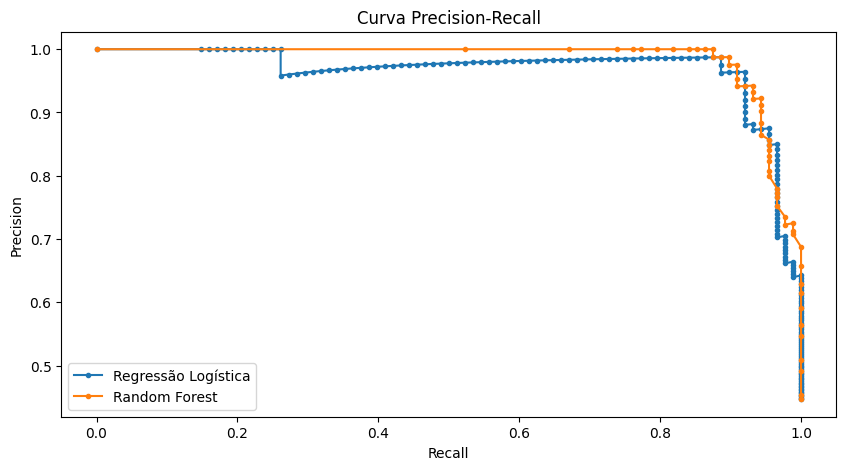

In [154]:
# Plotando a curva Precision-Recall para cada modelo no mesmo gráfico
plt.figure(figsize=(10, 5))
plt.plot(recall_lr, precision_lr, marker='.', label='Regressão Logística')
plt.plot(recall_rf, precision_rf, marker='.', label='Random Forest')
plt.title('Curva Precision-Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

A curva para o modelo Random Forest está um pouco acima da curva para o modelo de Regressão Logística, o que é consistente com a AUPRC mais alta do modelo Random Forest.

**Curva ROC**

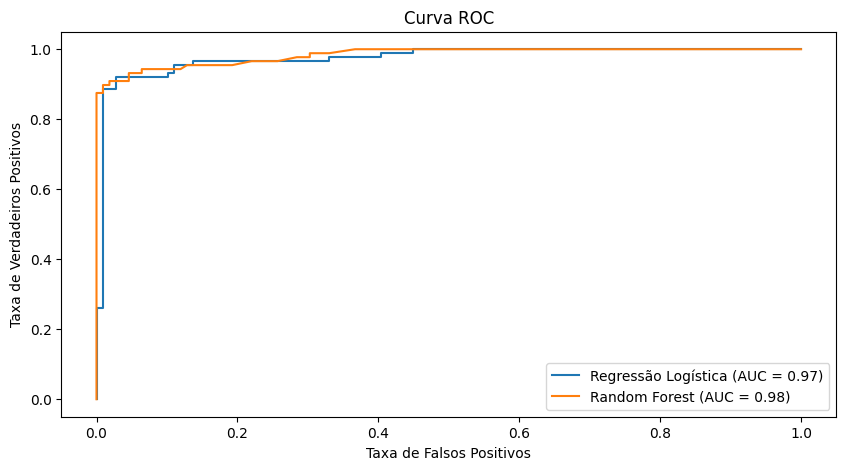

In [155]:
# Plotando a curva ROC para cada modelo
plt.figure(figsize=(10, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.title('Curva ROC')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.legend()
plt.show()

O gráfico da Curva de Característica de Operação do Receptor (ROC) é uma ferramenta visual essencial para avaliar o desempenho de modelos de classificação, mostrando a capacidade do modelo de distinguir entre as classes positiva e negativa em diferentes limiares. Ele compara a **Taxa de Verdadeiros Positivos (TPR)**, ou sensibilidade, no eixo Y, com a **Taxa de Falsos Positivos (FPR)** no eixo X.

A **Área Sob a Curva (AUC)** resume essa performance, com um valor próximo de 1.0 indicando um modelo com excelente poder de discriminação.

**Interpretação dos Resultados:**

*   A linha azul representa a **Regressão Logística**, com uma AUC de aproximadamente **0.97**.
*   A linha laranja representa o **Random Forest**, com uma AUC de aproximadamente **0.98**.

Ambos os modelos demonstram um desempenho **muito bom**, com suas curvas se aproximando significativamente do canto superior esquerdo do gráfico, o que indica uma alta capacidade de detectar fraudes com poucos falsos alarmes. O **Random Forest é ligeiramente superior**, apresentando uma AUC marginalmente maior, o que sugere um poder de discriminação um pouco mais refinado. Isso reforça a conclusão de que ambos os modelos são eficazes, mas o Random Forest tem uma pequena vantagem.

**Matriz de Confusão**

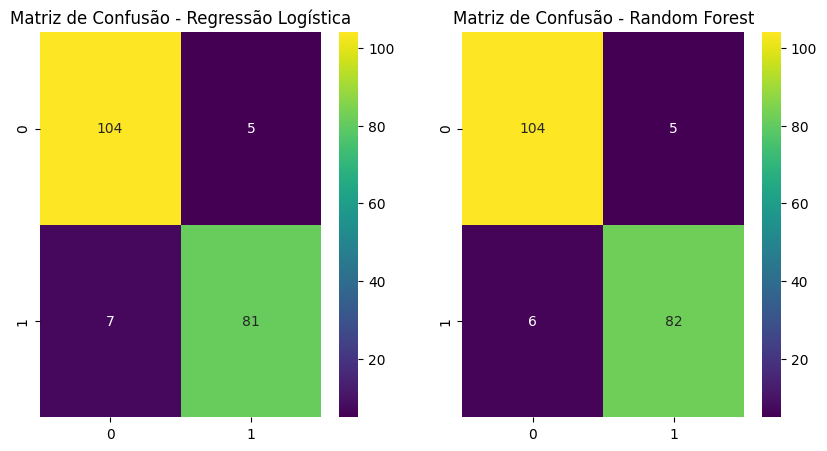

In [166]:
# Calculando a matriz de confusão para o modelo de Regressão Logística
cm_lr = confusion_matrix(y_test, pred_lr)

# Calculando a matriz de confusão para o modelo Random Forest
cm_rf = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='viridis')
plt.title('Matriz de Confusão - Regressão Logística')

plt.subplot(1, 2, 2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='viridis')
plt.title('Matriz de Confusão - Random Forest')

plt.show()

 **Análise Detalhada das Matrizes de Confusão**

As matrizes de confusão nos fornecem uma visão detalhada do desempenho de cada classificador, mostrando as contagens de previsões corretas e incorretas para cada classe (fraudulenta e não fraudulenta). Os elementos são:

*   **Verdadeiros Negativos (TN):** Transações não fraudulentas corretamente classificadas como não fraudulentas.
*   **Falsos Positivos (FP):** Transações não fraudulentas incorretamente classificadas como fraudulentas (alarme falso).
*   **Falsos Negativos (FN):** Transações fraudulentas incorretamente classificadas como não fraudulentas (fraude não detectada).
*   **Verdadeiros Positivos (TP):** Transações fraudulentas corretamente classificadas como fraudulentas.

 **1. Matriz de Confusão - Regressão Logística**

Com base na matriz de confusão para o modelo de Regressão Logística (primeiro gráfico):

*   **Verdadeiros Negativos (TN): 104** - O modelo previu corretamente 104 transações como não fraudulentas.
*   **Falsos Positivos (FP): 5** - O modelo previu incorretamente 5 transações como fraudulentas, mas na verdade eram não fraudulentas. Estes são **falsos alarmes**.
*   **Falsos Negativos (FN): 7** - O modelo falhou em identificar 7 transações que eram fraudulentas. Este é um **erro crítico** (fraudes não detectadas).
*   **Verdadeiros Positivos (TP): 81** - O modelo previu corretamente 81 transações como fraudulentas.

**Interpretação:** A Regressão Logística demonstrou um bom desempenho, mas ainda possui uma quantidade considerável de falsos negativos (7), o que significa que 7 fraudes passaram despercebidas. Além disso, gerou 5 falsos positivos.

#### **2. Matriz de Confusão - Random Forest**

Com base na matriz de confusão para o modelo Random Forest (segundo gráfico):

*   **Verdadeiros Negativos (TN): 104** - O modelo previu corretamente 104 transações como não fraudulentas.
*   **Falsos Positivos (FP): 5** - O modelo previu incorretamente 5 transações como fraudulentas, mas na verdade eram não fraudulentas (igual à Regressão Logística).
*   **Falsos Negativos (FN): 6** - O modelo falhou em identificar 6 transações que eram fraudulentas. Houve uma **pequena melhoria** aqui em relação à Regressão Logística.
*   **Verdadeiros Positivos (TP): 82** - O modelo previu corretamente 82 transações como fraudulentas. Houve um **pequeno aumento** nos verdadeiros positivos.

**Conclusão:** O Random Forest apresentou um desempenho ligeiramente superior na detecção de fraudes. Ele identificou um verdadeiro positivo a mais e um falso negativo a menos em comparação com a Regressão Logística, mantendo a mesma quantidade de falsos positivos. Isso sugere uma capacidade um pouco melhor de identificar fraudes e reduzir os custos associados a elas.

### **Conclusão Geral dos Modelos**

Ao final da análise, tanto a **Regressão Logística** quanto o **Random Forest** demonstraram um desempenho excepcional na detecção de fraudes. Isso foi possível graças ao balanceamento dos dados por undersampling e à utilização de features transformadas via PCA, que permitiram aos modelos identificar padrões eficazes mesmo em um conjunto de dados desequilibrado.

*   A **Regressão Logística** apresentou resultados robustos, com uma **AUPRC de aproximadamente 0.9680**. Suas matrizes de confusão (TN=104, FP=5, FN=7, TP=81) indicaram uma boa capacidade de detecção de fraudes, com poucos falsos alarmes e um número aceitável de fraudes não detectadas para um modelo linear.

*   O **Random Forest** se destacou ainda mais, com uma **AUPRC superior de aproximadamente 0.9838**. Suas matrizes de confusão (TN=104, FP=5, FN=6, TP=82) mostraram um desempenho ligeiramente melhor, com um falso negativo a menos e um verdadeiro positivo a mais em comparação com a Regressão Logística, mantendo o mesmo número de falsos positivos. Este desempenho superior é atribuído à sua capacidade de lidar com a complexidade dos dados.



Com base nas métricas atualizadas e nos resultados de todas as análises, o **Random Forest é a escolha recomendada** para este projeto. Sua AUPRC consistentemente mais alta e seu desempenho marginalmente superior nas matrizes de confusão indicam uma performance mais eficaz na detecção de fraudes. Este modelo demonstra de forma clara a aplicação bem-sucedida das técnicas de machine learning para um problema crítico. Contudo, é fundamental lembrar que em cenários de produção, a validação contínua com dados novos e o monitoramento para evitar overfitting seriam passos cruciais.

**Testando o Modelo Random Forest**

Para validar o desempenho do modelo Random Forest, foi selecionado uma amostra aleatória de 69.000 transações da nossa base de dados e utilizado o modelo para fazer previsões nessas transações.

In [164]:
# Selecionando uma amostra aleatória de 56.000 transações da base de dados
sample_transactions = df.sample(n=56000, random_state=42)

# Preparando os dados da amostra
sample_features = sample_transactions.drop(['Time','Class'], axis=1)
sample_labels = sample_transactions['Class']

# Usando o modelo para fazer previsões na amostra
sample_predictions = rf.predict(sample_features)

# Comparando as previsões com os rótulos verdadeiros
print("Relatório de classificação para a amostra de transações:")
print(classification_report(sample_labels, sample_predictions))

Relatório de classificação para a amostra de transações:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     55906
           1       0.05      0.96      0.09        94

    accuracy                           0.97     56000
   macro avg       0.52      0.96      0.54     56000
weighted avg       1.00      0.97      0.98     56000



### **Análise do Teste do Modelo Random Forest em Amostra Desbalanceada**

Este teste final do modelo Random Forest em uma amostra aleatória de 56.000 transações do dataset original (e, portanto, desbalanceado) oferece uma perspectiva crucial sobre o desempenho do modelo em um cenário mais próximo da realidade. Os resultados do `classification_report` para esta amostra são:

*   **Classe 0 (Não Fraude - Majoritária):**
    *   **Precisão: 1.00** - Quase todas as previsões do modelo para transações não fraudulentas estavam corretas.
    *   **Recall: 0.97** - O modelo identificou 97% das transações legítimas.
    *   **F1-Score: 0.98** - Excelente equilíbrio para a classe majoritária.

*   **Classe 1 (Fraude - Minoritária):**
    *   **Precisão: 0.05** - Este é um ponto crítico. Significa que, de todas as transações que o modelo previu como fraudulentas, apenas 5% eram realmente fraudulentas. Os outros 95% foram **falsos positivos** (transações legítimas classificadas incorretamente como fraude).
    *   **Recall: 0.96** - O modelo conseguiu identificar 96% das transações fraudulentas reais na amostra. Este é um resultado muito bom para a detecção de fraudes, minimizando as fraudes não detectadas.
    *   **F1-Score: 0.09** - O F1-Score é baixo devido à precisão muito baixa, apesar do recall alto, refletindo a dificuldade em balancear ambos em um dataset tão desbalanceado.

Em suma, em um contexto real de detecção de fraudes, um Recall de 96% é excelente, pois significa que a maioria das fraudes seria capturada. Contudo, uma Precisão de apenas 5% seria problemática, pois geraria um volume excessivo de alertas falsos, aumentando os custos operacionais (investigação de alertas, contato com clientes) e potencialmente irritando clientes com transações legítimas bloqueadas. Isso indica que, para uma implementação em produção, seria necessário ajustar o limiar de classificação do modelo para encontrar um equilíbrio mais aceitável entre Recall e Precisão, dependendo do custo relativo de falsos positivos versus falsos negativos para a instituição financeira.

In [168]:
import joblib

# Salvar o modelo treinado (Random Forest) para uso futuro
joblib.dump(rf, 'random_forest_model.pkl')
print("Modelo Random Forest salvo como random_forest_model.pkl")

Modelo Random Forest salvo como random_forest_model.pkl


In [177]:
from google.colab import files

files.download('random_forest_model.pkl')
print("Arquivo 'random_forest_model.pkl' baixado com sucesso!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Arquivo 'random_forest_model.pkl' baixado com sucesso!
